### ERUBA ECHIKA CHIMEZIRIM
## AI AND MACHINE LEARNING
### tr3/std/Aim/153

### CNN MODEL ON CURRENCY

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader, random_split, Dataset

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Reproducibility
SEED = 42
torch.manual_seed(SEED)

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="/Users/user/Desktop/VS Code Setup/Classes & Practices/Neural network/Exam Dataset/dataset/Train",
    transform=train_transform
)

In [4]:
print("Number of classes:", len(dataset.classes))

Number of classes: 7


In [5]:
print(dataset.classes)

['1Hundrednote', '2Hundrednote', '2Thousandnote', '5Hundrednote', 'Fiftynote', 'Tennote', 'Twentynote']


In [6]:
class_counts = Counter(dataset.targets)

for class_id, count in class_counts.items():
    print(dataset.classes[class_id], ":", count)

1Hundrednote : 22
2Hundrednote : 22
2Thousandnote : 21
5Hundrednote : 22
Fiftynote : 22
Tennote : 22
Twentynote : 22


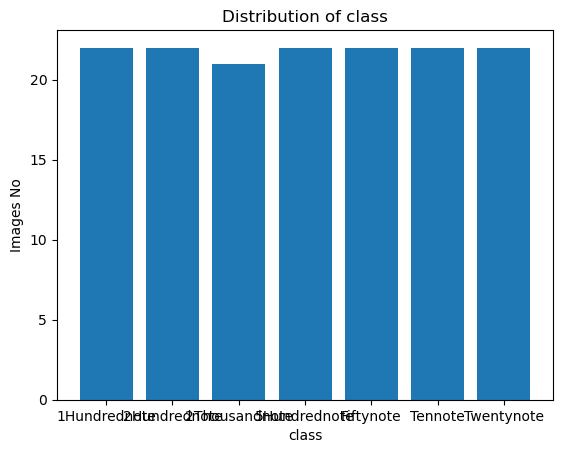

In [7]:
classes = list(dataset.classes)
counts = [class_counts[i] for i in range(len(classes))]

plt.bar(classes, counts)
plt.xlabel("class")
plt.ylabel("Images No")
plt.title("Distribution of class")
plt.show()

In [8]:
# Loop through the first 3 images in the dataset and print their tensor shape.
for i in range(3):
    img_tensor, label = dataset[i]
    print(f"Image {i+1} - Shape: {img_tensor.shape} "
          f"(Channels: {img_tensor.shape[0]}, Height: {img_tensor.shape[1]}, Width: {img_tensor.shape[2]})")

Image 1 - Shape: torch.Size([3, 64, 64]) (Channels: 3, Height: 64, Width: 64)
Image 2 - Shape: torch.Size([3, 64, 64]) (Channels: 3, Height: 64, Width: 64)
Image 3 - Shape: torch.Size([3, 64, 64]) (Channels: 3, Height: 64, Width: 64)


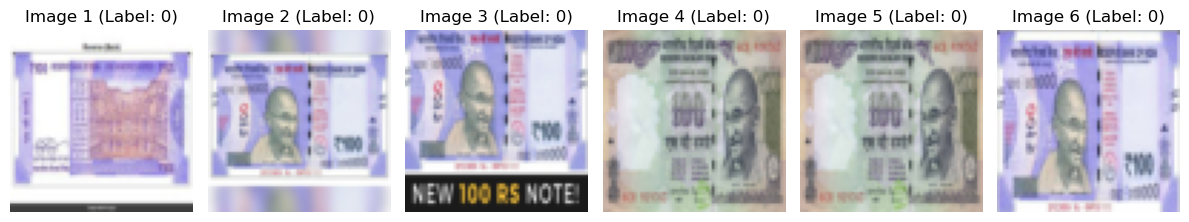

In [9]:
# Visualize the first 6 images to make sure loading/labeling looks correct.
fig, axes = plt.subplots(1, 6, figsize=(12, 4))

for i in range(6):
    img_tensor, label = dataset[i]
    img_to_show = img_tensor.permute(1, 2, 0)

    axes[i].imshow(img_to_show)
    axes[i].set_title(f"Image {i+1} (Label: {label})")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [10]:
# We temporarily load the (un-normalized) dataset in batches just to measure its statistics.
loader = DataLoader(dataset, batch_size=8, shuffle=False)

mean = 0.
std = 0.
total_images = 0

for images, _ in loader:
    batch_size = images.size(0)

    # Flatten each image's H x W pixels into a single dimension per channel
    images = images.view(batch_size, images.size(1), -1)

    # .mean(2) / .std(2) average over the pixel dimension, giving one
    # value per channel per image;
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)

    total_images += batch_size

mean /= total_images
std /= total_images

print("Dataset mean (per channel):", mean)
print("Dataset std  (per channel):", std)

# FIX: actually keep the computed Normalize transform so it can be reused
# consistently everywhere below, instead of throwing it away.
dataset_normalize = transforms.Normalize(
    mean=mean.tolist(),
    std=std.tolist()
)

Dataset mean (per channel): tensor([0.7191, 0.6684, 0.6404])
Dataset std  (per channel): tensor([0.1629, 0.1767, 0.1783])


In [11]:
# Train transform
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    dataset_normalize
])

# Evaluation transform
eval_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    dataset_normalize
])

# Re-load the training dataset with the now-complete (normalized) transform.
dataset = datasets.ImageFolder(
    root="/Users/user/Desktop/VS Code Setup/Classes & Practices/Neural network/Exam Dataset/dataset/Train",
    transform=train_transform
)


test_dataset = datasets.ImageFolder(
    root="/Users/user/Desktop/VS Code Setup/Classes & Practices/Neural network/Exam Dataset/dataset/Test",
    transform=eval_transform
)

In [12]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

print("Original dataset:", len(dataset))
print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Original dataset: 153
Training dataset: 122
Validation dataset: 31
Test dataset: 42


In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

# Peek at one batch to confirm shapes:
# images: (batch_size, channels, height, width)
# labels: (batch_size,)
for images, labels in train_loader:
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    break

Image batch shape: torch.Size([8, 3, 64, 64])
Label batch shape: torch.Size([8])


In [14]:
from torch import nn

model_cnn = nn.Sequential(

    # Convolution block 1 
    nn.Conv2d(
        in_channels=3,
        out_channels=16,
        kernel_size=3,
        stride=1,
        padding=1
    ),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    # ---- Convolution block 2 ----
    nn.Conv2d(
        in_channels=16,
        out_channels=32,
        kernel_size=3,
        stride=1,
        padding=1
    ),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    # Convert feature maps to vector
    nn.Flatten(),

    # Fully connected hidden layer
    nn.Linear(32 * 16 * 16, 128),
    nn.ReLU(),

    # Output layer: 4 classes
    nn.Linear(128, 7)
)

print(model_cnn)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=8192, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=7, bias=True)
)


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


class CNNClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 7)

    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        # Block 2
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        # Classifier head
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)   

        return x


model = CNNClassifier().to(device)

# CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Adam Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.002)

Using device: cpu


In [16]:
num_epochs = 20

for epoch in range(num_epochs):
    model.train()  # enables training-specific behavior (relevant once we add BatchNorm/Dropout later)

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

    
        train_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    average_train_loss = train_loss / train_total
    train_accuracy = 100 * train_correct / train_total

    print(f"Epoch [{epoch + 1}/{num_epochs}] | "
          f"Train Loss: {average_train_loss:.4f} | "
          f"Train Accuracy: {train_accuracy:.2f}%")

Epoch [1/20] | Train Loss: 2.0683 | Train Accuracy: 22.95%
Epoch [2/20] | Train Loss: 1.4561 | Train Accuracy: 47.54%
Epoch [3/20] | Train Loss: 0.8920 | Train Accuracy: 63.93%
Epoch [4/20] | Train Loss: 0.6582 | Train Accuracy: 74.59%
Epoch [5/20] | Train Loss: 0.3616 | Train Accuracy: 92.62%
Epoch [6/20] | Train Loss: 0.2354 | Train Accuracy: 92.62%
Epoch [7/20] | Train Loss: 0.3544 | Train Accuracy: 87.70%
Epoch [8/20] | Train Loss: 0.2705 | Train Accuracy: 94.26%
Epoch [9/20] | Train Loss: 0.0948 | Train Accuracy: 96.72%
Epoch [10/20] | Train Loss: 0.1065 | Train Accuracy: 97.54%
Epoch [11/20] | Train Loss: 0.0294 | Train Accuracy: 99.18%
Epoch [12/20] | Train Loss: 0.0108 | Train Accuracy: 100.00%
Epoch [13/20] | Train Loss: 0.0038 | Train Accuracy: 100.00%
Epoch [14/20] | Train Loss: 0.0025 | Train Accuracy: 100.00%
Epoch [15/20] | Train Loss: 0.0019 | Train Accuracy: 100.00%
Epoch [16/20] | Train Loss: 0.0014 | Train Accuracy: 100.00%
Epoch [17/20] | Train Loss: 0.0012 | Train A

In [17]:
model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)
        test_correct += (predictions == labels).sum().item()
        test_total += labels.size(0)

average_test_loss = test_loss / test_total
test_accuracy = 100 * test_correct / test_total

print("Baseline CNN (Test Results)")
print(f"Test Loss: {average_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Baseline CNN (Test Results)
Test Loss: 0.2944
Test Accuracy: 85.71%


In [18]:
class BalancedTrainDataset(Dataset):

    def __init__(self, samples, classes, transform, target_size):
        self.classes = classes
        self.transform = transform

        # Group the given (training-only) samples by class label
        class_images = {i: [] for i in range(len(classes))}
        for path, label in samples:
            class_images[label].append(path)

        self.samples = []
        for label, paths in class_images.items():
            n = len(paths)

            # Keep every original image
            for path in paths:
                self.samples.append((path, label))

            # Duplicate paths (cycling through the class's images) until
            # this class reaches target_size samples
            for i in range(max(0, target_size - n)):
                path = paths[i % n]
                self.samples.append((path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        image = self.transform(image)
        return image, label


class EvalDataset(Dataset):
   
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        image = self.transform(image)
        return image, label

In [19]:
augmentation_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    dataset_normalize
])

# Load the raw (untransformed) sample list once, just to get file paths + labels
raw_dataset = ImageFolder(root="/Users/user/Desktop/VS Code Setup/Classes & Practices/Neural network/Exam Dataset/dataset/Train")
classes = raw_dataset.classes
all_samples = raw_dataset.samples  # list of (path, label)

# split the ORIGINAL, non-duplicated samples into train/validation portions BEFORE any oversampling happens.
train_samples, val_samples = [], []
by_class = {i: [] for i in range(len(classes))}
for path, label in all_samples:
    by_class[label].append((path, label))

g = torch.Generator().manual_seed(SEED)
for label, items in by_class.items():
    n = len(items)
    perm = torch.randperm(n, generator=g).tolist()
    split_point = int(0.8 * n)
    train_samples += [items[i] for i in perm[:split_point]]
    val_samples += [items[i] for i in perm[split_point:]]

# Only the TRAINING portion gets oversampled + augmented
balanced_train_dataset = BalancedTrainDataset(
    samples=train_samples,
    classes=classes,
    transform=augmentation_transform,
    target_size=22
)

# Validation portion: one copy per image, no augmentation
balanced_val_dataset = EvalDataset(
    samples=val_samples,
    transform=eval_transform
)

print("Original dataset:", len(all_samples))
print("Balanced training dataset (with oversampling):", len(balanced_train_dataset))
print("Validation dataset (untouched, no duplication):", len(balanced_val_dataset))

Original dataset: 153
Balanced training dataset (with oversampling): 154
Validation dataset (untouched, no duplication): 35


In [20]:
# Check the resulting class balance in the training set
labels_in_train = [label for _, label in balanced_train_dataset.samples]
counts = Counter(labels_in_train)

print("Class distribution after balancing (training set):")
for label, count in counts.items():
    print(f"  {classes[label]}: {count}")

Class distribution after balancing (training set):
  1Hundrednote: 22
  2Hundrednote: 22
  2Thousandnote: 22
  5Hundrednote: 22
  Fiftynote: 22
  Tennote: 22
  Twentynote: 22


In [21]:
train_loader = DataLoader(
    balanced_train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    balanced_val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

In [22]:
from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class RegularizedCNN(nn.Module):

    def __init__(self):
        super().__init__()

        # ---- Convolutional feature extractor ----
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(128)

        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(256)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()

        # After 5 pooling operations: 64 -> 32 -> 16 -> 8 -> 4 -> 2
        # Final feature maps: 256 channels x 2 x 2 = 1024 features
        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.dropout = nn.Dropout(0.40)
        self.fc2 = nn.Linear(256, 7)  # output layer: 4 classes

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))
        x = self.pool(self.relu(self.bn5(self.conv5(x))))

        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


model = RegularizedCNN().to(device)

summary(model, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
RegularizedCNN                           [1, 7]                    --
├─Conv2d: 1-1                            [1, 16, 64, 64]           448
├─BatchNorm2d: 1-2                       [1, 16, 64, 64]           32
├─ReLU: 1-3                              [1, 16, 64, 64]           --
├─MaxPool2d: 1-4                         [1, 16, 32, 32]           --
├─Conv2d: 1-5                            [1, 32, 32, 32]           4,640
├─BatchNorm2d: 1-6                       [1, 32, 32, 32]           64
├─ReLU: 1-7                              [1, 32, 32, 32]           --
├─MaxPool2d: 1-8                         [1, 32, 16, 16]           --
├─Conv2d: 1-9                            [1, 64, 16, 16]           18,496
├─BatchNorm2d: 1-10                      [1, 64, 16, 16]           128
├─ReLU: 1-11                             [1, 64, 16, 16]           --
├─MaxPool2d: 1-12                        [1, 64, 8, 8]             --
├─Conv

In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4  # L2-style regularization: penalizes large weights
)

In [24]:
num_epochs = 50

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):

    # ---- Training ----
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        predictions = torch.argmax(outputs, dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    average_train_loss = train_loss / train_total
    train_accuracy = 100 * train_correct / train_total

    # ---- Validation ----
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            predictions = torch.argmax(outputs, dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    average_val_loss = val_loss / val_total
    val_accuracy = 100 * val_correct / val_total

    history["train_loss"].append(average_train_loss)
    history["train_acc"].append(train_accuracy)
    history["val_loss"].append(average_val_loss)
    history["val_acc"].append(val_accuracy)

    print(f"Epoch [{epoch + 1}/{num_epochs}] | "
          f"Train Loss: {average_train_loss:.4f} | Train Acc: {train_accuracy:.2f}% | "
          f"Val Loss: {average_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

Epoch [1/50] | Train Loss: 2.0014 | Train Acc: 27.92% | Val Loss: 1.7465 | Val Acc: 31.43%
Epoch [2/50] | Train Loss: 1.3756 | Train Acc: 41.56% | Val Loss: 2.1370 | Val Acc: 34.29%
Epoch [3/50] | Train Loss: 1.3510 | Train Acc: 50.00% | Val Loss: 1.3397 | Val Acc: 37.14%
Epoch [4/50] | Train Loss: 1.1587 | Train Acc: 54.55% | Val Loss: 1.5061 | Val Acc: 45.71%
Epoch [5/50] | Train Loss: 1.0768 | Train Acc: 59.09% | Val Loss: 1.0521 | Val Acc: 57.14%
Epoch [6/50] | Train Loss: 1.1004 | Train Acc: 57.14% | Val Loss: 1.2366 | Val Acc: 51.43%
Epoch [7/50] | Train Loss: 0.8500 | Train Acc: 66.23% | Val Loss: 1.0244 | Val Acc: 65.71%
Epoch [8/50] | Train Loss: 1.0992 | Train Acc: 60.39% | Val Loss: 1.1797 | Val Acc: 62.86%
Epoch [9/50] | Train Loss: 0.8372 | Train Acc: 66.88% | Val Loss: 1.0796 | Val Acc: 60.00%
Epoch [10/50] | Train Loss: 0.9953 | Train Acc: 63.64% | Val Loss: 1.2355 | Val Acc: 60.00%
Epoch [11/50] | Train Loss: 0.9602 | Train Acc: 62.34% | Val Loss: 0.8509 | Val Acc: 62.8

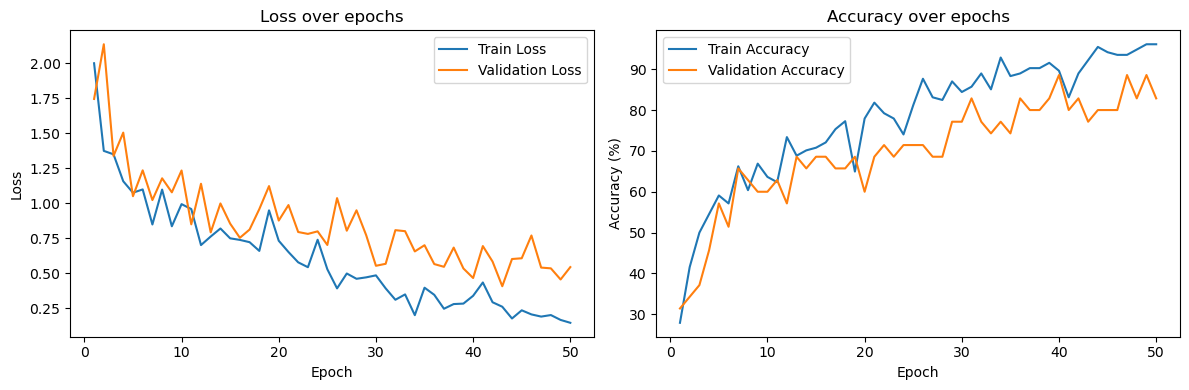

In [25]:
# Plot training curves
epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over epochs")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Accuracy")
axes[1].plot(epochs_range, history["val_acc"], label="Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy over epochs")
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
model.eval()

test_loss, test_correct, test_total = 0.0, 0, 0
true_labels, predicted_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        predictions = torch.argmax(outputs, dim=1)
        test_correct += (predictions == labels).sum().item()
        test_total += labels.size(0)

        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predictions.cpu().numpy())

average_test_loss = test_loss / test_total
test_accuracy = 100 * test_correct / test_total

print("Regularized CNN — Test Results")
print(f"Test Loss: {average_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%\n")

print("Classification report:")
print(classification_report(true_labels, predicted_labels, target_names=classes, zero_division = 0))

print("Confusion matrix (rows = true class, columns = predicted class):")
print(confusion_matrix(true_labels, predicted_labels))

Regularized CNN — Test Results
Test Loss: 0.2887
Test Accuracy: 95.24%

Classification report:
               precision    recall  f1-score   support

 1Hundrednote       1.00      1.00      1.00         6
 2Hundrednote       0.86      1.00      0.92         6
2Thousandnote       0.86      1.00      0.92         6
 5Hundrednote       1.00      0.67      0.80         6
    Fiftynote       1.00      1.00      1.00         6
      Tennote       1.00      1.00      1.00         6
   Twentynote       1.00      1.00      1.00         6

     accuracy                           0.95        42
    macro avg       0.96      0.95      0.95        42
 weighted avg       0.96      0.95      0.95        42

Confusion matrix (rows = true class, columns = predicted class):
[[6 0 0 0 0 0 0]
 [0 6 0 0 0 0 0]
 [0 0 6 0 0 0 0]
 [0 1 1 4 0 0 0]
 [0 0 0 0 6 0 0]
 [0 0 0 0 0 6 0]
 [0 0 0 0 0 0 6]]


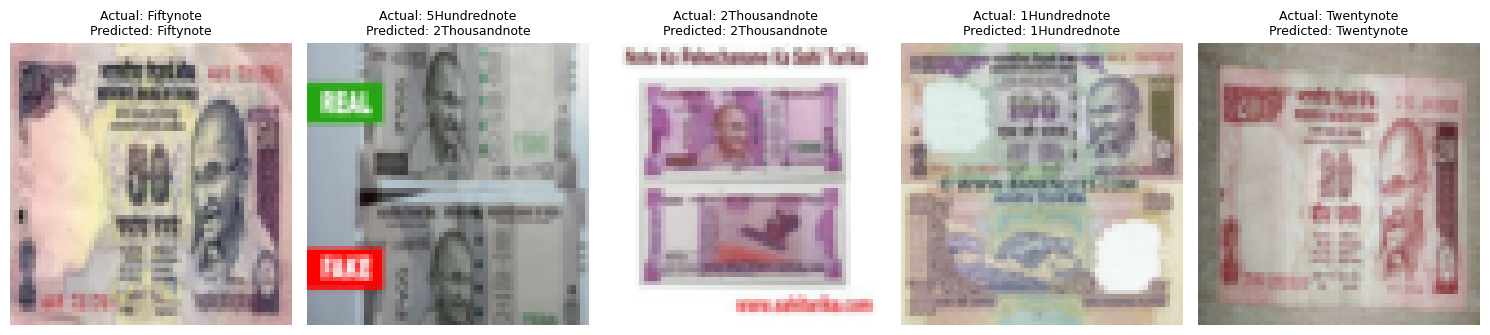

In [28]:
import random
import matplotlib.pyplot as plt

model.eval()

# Pick 5 random indices from the test set
sample_indices = random.sample(range(len(test_dataset)), 5)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

with torch.no_grad():
    for ax, idx in zip(axes, sample_indices):
        image, true_label = test_dataset[idx]

        # Model expects a batch dimension: (1, C, H, W)
        output = model(image.unsqueeze(0).to(device))
        predicted_label = torch.argmax(output, dim=1).item()

        # Undo normalization just for display purposes
        img_display = image.clone()
        for c in range(3):
            img_display[c] = img_display[c] * std[c] + mean[c]
        img_display = img_display.permute(1, 2, 0).clamp(0, 1)

        ax.imshow(img_display)
        ax.set_title(f"Actual: {classes[true_label]}\nPredicted: {classes[predicted_label]}",
                     fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()